In [ ]:
!pip install pennylane
!pip install tensorflow
!pip install opencv-python
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 51.4 MB/s eta 0:00:00


In [ ]:
!pip install matplotlib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/Medical_AI_Project"

HAM10000


In [ ]:
!ls "/content/drive/MyDrive/Medical_AI_Project/HAM10000"

HAM10000_images_part_1	HAM10000_images_part_2	HAM10000_metadata.csv


In [ ]:
!cp -r /content/drive/MyDrive/Medical_AI_Project/HAM10000 /content/


In [ ]:
!ls /content/HAM10000

HAM10000_images_part_1	HAM10000_images_part_2	HAM10000_metadata.csv


In [ ]:
import os

os.listdir("/content/HAM10000")

['HAM10000_images_part_2', 'HAM10000_metadata.csv', 'HAM10000_images_part_1']

In [ ]:
import pandas as pd

metadata = pd.read_csv("/content/HAM10000/HAM10000_metadata.csv")
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
import os

dataset_path = "/content/HAM10000"

part1 = os.path.join(dataset_path, "HAM10000_images_part_1")
part2 = os.path.join(dataset_path, "HAM10000_images_part_2")


In [ ]:
def get_image_path(image_id):

    img_name = image_id + ".jpg"

    path1 = os.path.join(part1, img_name)
    path2 = os.path.join(part2, img_name)

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None


In [ ]:
import cv2
import numpy as np

def load_images(df, size=64):

    images = []
    labels = []

    for _, row in df.iterrows():

        img_path = get_image_path(row['image_id'])

        if img_path is not None:

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (size, size))

            images.append(img)
            labels.append(row['dx'])

    return np.array(images), np.array(labels)


In [ ]:

X, y = load_images(metadata)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Images Shape: (10015, 64, 64, 3)
Labels Shape: (10015,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


In [ ]:
X = X / 255.0
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

y_cat = to_categorical(y_encoded)

print("Classes:", encoder.classes_)
print("y_cat shape:", y_cat.shape)


Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
y_cat shape: (10015, 7)


In [ ]:
Dense(y_cat.shape[1], activation='softmax')
print(y_cat.shape)


(10015, 7)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([

    Input(shape=(64,64,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(y_cat.shape[1], activation='softmax')
])


In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(y_train.shape)


(8012, 64, 64, 3)
(8012, 7)


In [ ]:
print(X_test.shape)
print(y_test.shape)


(2003, 64, 64, 3)
(2003, 7)


In [ ]:
print(X_test.shape)
print(y_test.shape)

(2003, 64, 64, 3)
(2003, 7)


In [ ]:
print(X_train.shape[0] + X_test.shape[0])


10015


In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 222ms/step - accuracy: 0.6664 - loss: 1.0085 - val_accuracy: 0.6690 - val_loss: 0.9285
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.6756 - loss: 0.9014 - val_accuracy: 0.6655 - val_loss: 0.9302
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 198ms/step - accuracy: 0.6850 - loss: 0.8563 - val_accuracy: 0.6740 - val_loss: 0.8619
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 54s 215ms/step - accuracy: 0.6932 - loss: 0.8235 - val_accuracy: 0.6870 - val_loss: 0.8101
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 80s 206ms/step - accuracy: 0.6988 - loss: 0.8084 - val_accuracy: 0.6945 - val_loss: 0.8041
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.7146 - loss: 0.7688 - val_accuracy: 0.7059 - val_loss: 0.7895
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 205ms/step - accuracy: 0.7189 - loss: 0.7475 - val_accuracy: 0.7089 - val_loss: 0.7491
Epoch 8/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 194ms/step - accuracy: 0.7288 - loss: 0

In [ ]:
loss, acc = cnn_model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7309 - loss: 0.8784
Test Accuracy: 0.7309036254882812


In [ ]:
!pip install pennylane


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 46.0 MB/s eta 0:00:00


In [ ]:

import pennylane as qml
from pennylane import numpy as pnp

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_layer(inputs):

    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    for i in range(n_qubits-1):
        qml.CNOT(wires=[i, i+1])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
def run_quantum(features):
    return np.array([quantum_layer(f[:n_qubits]) for f in features])
cnn_model.predict(X_train[:1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


array([[2.4340677e-18, 3.5046236e-14, 1.6318532e-04, 1.9864230e-11,
        3.8703149e-10, 9.9983680e-01, 5.1085955e-16]], dtype=float32)

In [ ]:
import tensorflow as tf

feature_extractor = tf.keras.Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.layers[-3].output
)

cnn_features_train = feature_extractor.predict(X_train)
cnn_features_test = feature_extractor.predict(X_test)

print(cnn_features_train.shape)

251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
(8012, 128)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


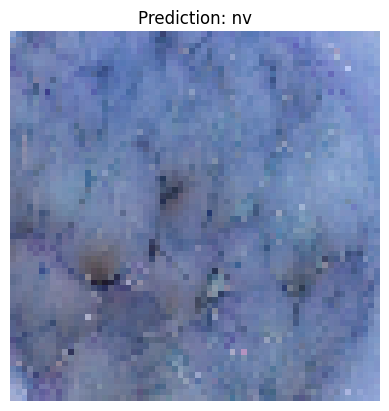

In [ ]:
import matplotlib.pyplot as plt

def show_prediction(index):

    img = X_test[index]
    pred = cnn_model.predict(np.expand_dims(img, axis=0))

    label = encoder.inverse_transform([np.argmax(pred)])[0]

    plt.imshow(img)
    plt.title(f"Prediction: {label}")
    plt.axis('off')

show_prediction(5)



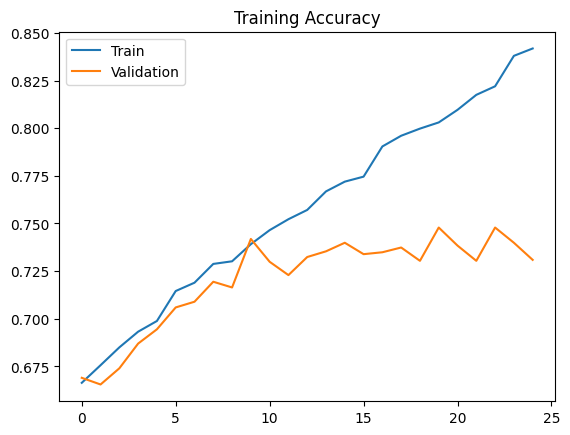

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training Accuracy")
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
!ls


drive  HAM10000  sample_data  version.json


In [ ]:
cnn_model.save("hqcnn_medical_model.keras")


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("hqcnn_medical_model.keras" ,compile=False)


In [ ]:
import json

with open("training_history.json", "w") as f:
    json.dump(history.history, f)


In [ ]:
import os

os.path.exists("hqcnn_medical_model.keras")

True

In [ ]:
!ls


drive	  hqcnn_medical_model.keras  training_history.json
HAM10000  sample_data		     version.json


In [ ]:
from tensorflow.keras.models import load_model

test_model = load_model("hqcnn_medical_model.keras", compile=False)
print("Model loaded successfully")


Model loaded successfully


In [ ]:
import json

with open("training_history.json", "r") as f:
    history_data = json.load(f)

print(history_data.keys())


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
files_to_check = [
    "hqcnn_medical_model.keras",
    "label_encoder.pkl",
    "training_history.json"
]

for file in files_to_check:
    print(file, ":", os.path.exists(file))


hqcnn_medical_model.keras : True
label_encoder.pkl : False
training_history.json : True


In [ ]:
from google.colab import files

files.download("hqcnn_medical_model.keras")

files.download("training_history.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)


In [ ]:
import os
print(os.path.exists("label_encoder.pkl"))


True


In [ ]:
from google.colab import files
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
import keras
import numpy
print(tf.__version__)
print(keras.__version__)
print(np.__version__)

2.19.0
3.13.2
2.0.2
